     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=d6258651f60fc6114e460959e3159d04503fd301fb36a053d4606f75a0336a28
  Stored in directory: /root/.cache/pip/wheels/05/bd/e2/0c0eecf3c26b6cdb231b5656d53905bddc8090d69619d57e6b
Successfully built grad-cam

===== DENSENET121 =====
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 155MB/s]


Backbone unfreeze...
Early stopping.

===== RESNET50 =====
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Backbone unfreeze...
Early stopping.

===== EFFICIENTNET_B0 =====
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s] 


Backbone unfreeze...
Early stopping.
             Model    Val F1   Test F1  Test ROC-AUC
2  efficientnet_b0  0.957641  0.979063      0.994383
0      densenet121  0.985880  0.978642      0.999682
1         resnet50  0.946895  0.903255      0.996550

The most powerful single backbone: efficientnet_b0 (Test F1 = 0.9791)

=== SOFT VOTING ===
F1: 0.9826016260162601
ROC-AUC: 0.9996701576154163


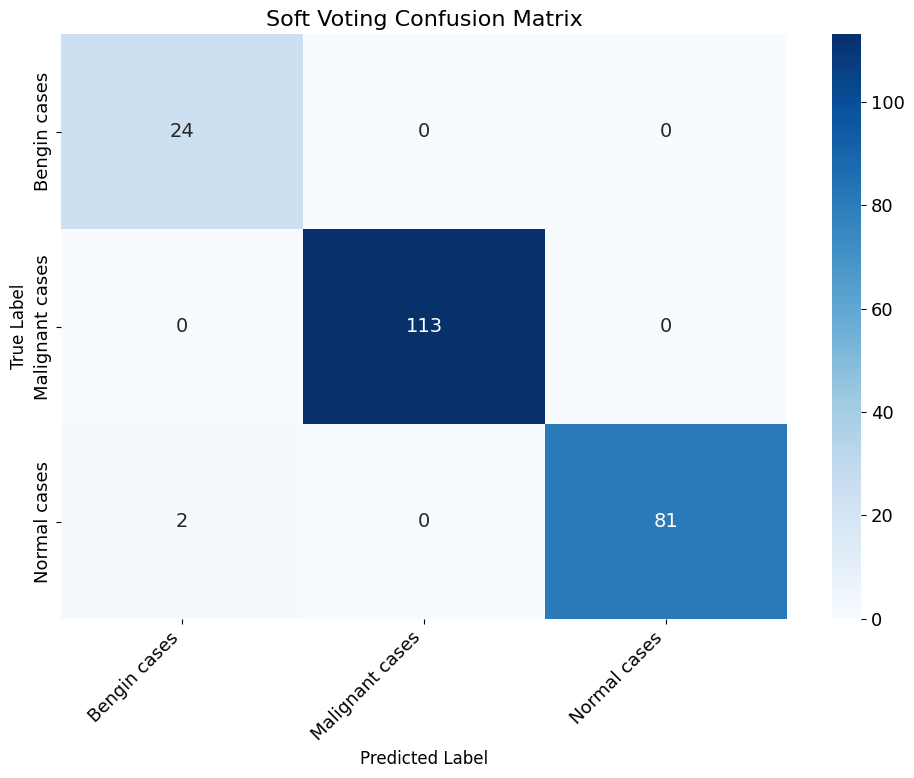

                 precision    recall  f1-score   support

   Bengin cases       0.92      1.00      0.96        24
Malignant cases       1.00      1.00      1.00       113
   Normal cases       1.00      0.98      0.99        83

       accuracy                           0.99       220
      macro avg       0.97      0.99      0.98       220
   weighted avg       0.99      0.99      0.99       220

Kaydedildi -> lung_ct_test_predictions.npz


In [1]:
# =========================
# 0. IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
!pip install grad-cam
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
!pip install grad-cam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "svg.fonttype": "none"   # Fontlar metin olarak kalsın (çok önemli!)
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

# =========================
# 1. DATA PREPARATION
# =========================
BASE_DIR = "/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset"

class_map = {
    "Bengin cases": 0,
    "Malignant cases": 1,
    "Normal cases": 2
}

filepaths, labels = [], []

for folder, label in class_map.items():
    folder_path = os.path.join(BASE_DIR, folder)
    for f in os.listdir(folder_path):
        filepaths.append(os.path.join(folder_path, f))
        labels.append(label)

df = pd.DataFrame({"path": filepaths, "label": labels})

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df["label"], random_state=42
)

# =========================
# 2. DATASET CLASS
# =========================
class LungDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "path"]).convert("RGB")
        label = self.df.loc[idx, "label"]
        if self.transform:
            img = self.transform(img)
        return img, label

train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

BATCH_SIZE = 16

train_loader = DataLoader(LungDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LungDataset(val_df, val_test_tfms), batch_size=BATCH_SIZE)
test_loader  = DataLoader(LungDataset(test_df, val_test_tfms), batch_size=BATCH_SIZE)

# =========================
# 3. CLASS WEIGHTS
# =========================
class_counts = train_df["label"].value_counts().sort_index()
weights = 1.0 / class_counts
weights = weights / weights.sum()
class_weights = torch.tensor(weights.values, dtype=torch.float).to(DEVICE)

# =========================
# 4. TRAIN & EVAL FUNCTIONS
# =========================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds, targets = 0, [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        optimizer.step()

        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(y.cpu().numpy())

    return (
        total_loss / len(loader),
        f1_score(targets, preds, average="macro"),
        accuracy_score(targets, preds)
    )


def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, preds, probs, targets = 0, [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds.extend(out.argmax(1).cpu().numpy())
            probs.extend(torch.softmax(out,1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    return (
        total_loss / len(loader),
        f1_score(targets, preds, average="macro"),
        accuracy_score(targets, preds),
        np.array(probs),
        np.array(targets)
    )

# =========================
# 5. MODEL TRAINING
# =========================
model_names = ["densenet121", "resnet50", "efficientnet_b0"]
all_histories = {}
results_list = []
test_probs_per_model = {}
for m_name in model_names:
    print(f"\n===== {m_name.upper()} =====")

    if m_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, 3)

    elif m_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, 3)

    elif m_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

    model = model.to(DEVICE)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    if m_name == "densenet121":
        for param in model.classifier.parameters():
            param.requires_grad = True
    elif m_name == "resnet50":
        for param in model.fc.parameters():
            param.requires_grad = True
    else:
        for param in model.classifier.parameters():
            param.requires_grad = True

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=3e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    history = {"train_loss":[], "val_loss":[],
               "train_acc":[], "val_acc":[],
               "train_f1":[], "val_f1":[]}

    best_f1 = 0
    patience = 7
    counter = 0
    save_path = f"best_{m_name}.pth"

    for epoch in range(50):

        if epoch == 5:
            print("Backbone unfreeze...")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

        tr_loss, tr_f1, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_f1, val_acc, val_probs, val_targets = eval_one_epoch(model, val_loader, criterion)

        scheduler.step(val_f1)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping.")
            break

    all_histories[m_name] = history

    model.load_state_dict(torch.load(save_path))
    _, test_f1, _, y_prob, y_true = eval_one_epoch(model, test_loader, criterion)
    test_probs_per_model[m_name] = y_prob   # <-- YENİ
    test_true_shared = y_true

    roc_auc = roc_auc_score(
        torch.nn.functional.one_hot(torch.tensor(y_true), num_classes=3),
        y_prob,
        multi_class="ovr"
    )

    results_list.append({
        "Model": m_name,
        "Val F1": best_f1,
        "Test F1": test_f1,
        "Test ROC-AUC": roc_auc
    })

# =========================
# 6. RESULTS TABLE
# =========================
comparison_df = pd.DataFrame(results_list)
print(comparison_df.sort_values("Test F1", ascending=False))
best_single_name  = comparison_df.sort_values("Test F1", ascending=False).iloc[0]["Model"]
best_single_probs = test_probs_per_model[best_single_name]
print(f"\nThe most powerful single backbone: {best_single_name} (Test F1 = {comparison_df.sort_values('Test F1', ascending=False).iloc[0]['Test F1']:.4f})")
# =========================
# 7. SOFT VOTING ENSEMBLE
# =========================
loaded_models = {}
for m_name in model_names:
    if m_name == "densenet121":
        model = models.densenet121()
        model.classifier = nn.Linear(model.classifier.in_features, 3)
    elif m_name == "resnet50":
        model = models.resnet50()
        model.fc = nn.Linear(model.fc.in_features, 3)
    else:
        model = models.efficientnet_b0()
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

    model.load_state_dict(torch.load(f"best_{m_name}.pth"))
    model = model.to(DEVICE)
    model.eval()
    loaded_models[m_name] = model

def soft_voting(models_dict, loader):
    all_probs = []
    y_true = []

    for model in models_dict.values():
        _, _, _, probs, targets = eval_one_epoch(model, loader, criterion)
        all_probs.append(probs)
        y_true = targets

    avg_probs = np.mean(all_probs, axis=0)
    preds = np.argmax(avg_probs, axis=1)

    return preds, avg_probs, y_true

voting_preds, voting_probs, y_true = soft_voting(loaded_models, test_loader)

print("\n=== SOFT VOTING ===")
print("F1:", f1_score(y_true, voting_preds, average="macro"))
print("ROC-AUC:", roc_auc_score(
    torch.nn.functional.one_hot(torch.tensor(y_true), num_classes=3),
    voting_probs,
    multi_class="ovr"
))

# =========================
# 8. CONFUSION MATRIX
# =========================

plt.figure(figsize=(10, 8)) # Görsel boyutunu biraz büyütmek detayları netleştirir

cm = confusion_matrix(y_true, voting_preds)

# cmap="Blues" ile mavi tonlarını aktifleştiriyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=class_map.keys(),
            yticklabels=class_map.keys())

plt.title("Soft Voting Confusion Matrix", fontsize=16)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)

# X ekseni etiketlerini 45 derece döndürerek hizalıyoruz
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Etiketlerin kesilmesini önler
plt.show()

print(classification_report(y_true, voting_preds, target_names=list(class_map.keys())))
np.savez(
    "lung_ct_test_predictions.npz",
    y_true=y_true,
    probs_ensemble=voting_probs,
    best_single_name=best_single_name,
    **{f"probs_{k}": v for k, v in test_probs_per_model.items()}
)
print("Kaydedildi -> lung_ct_test_predictions.npz")

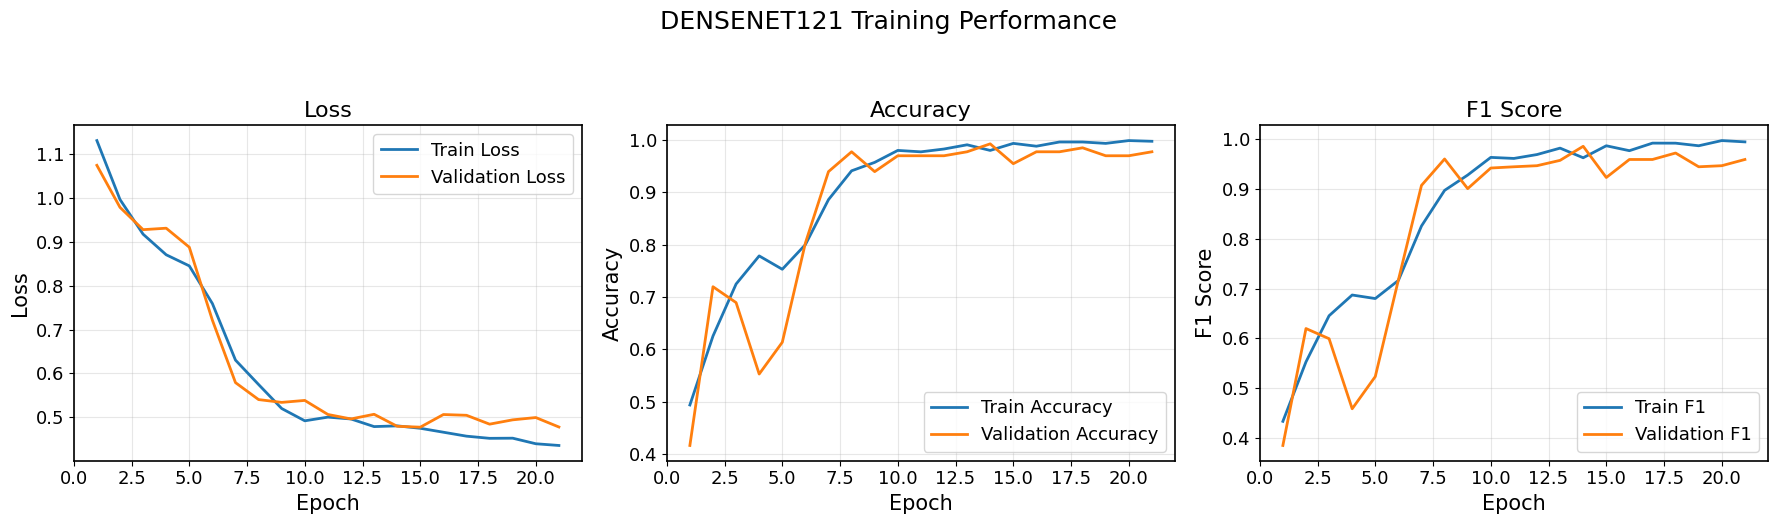

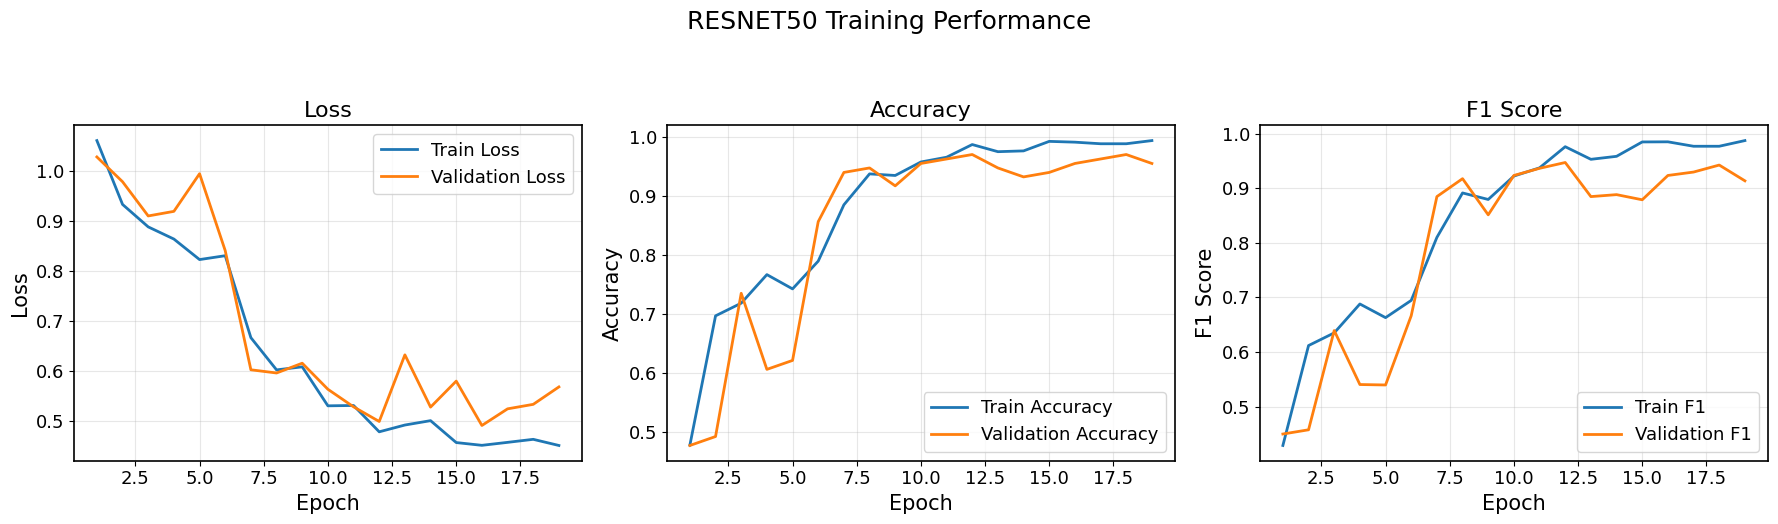

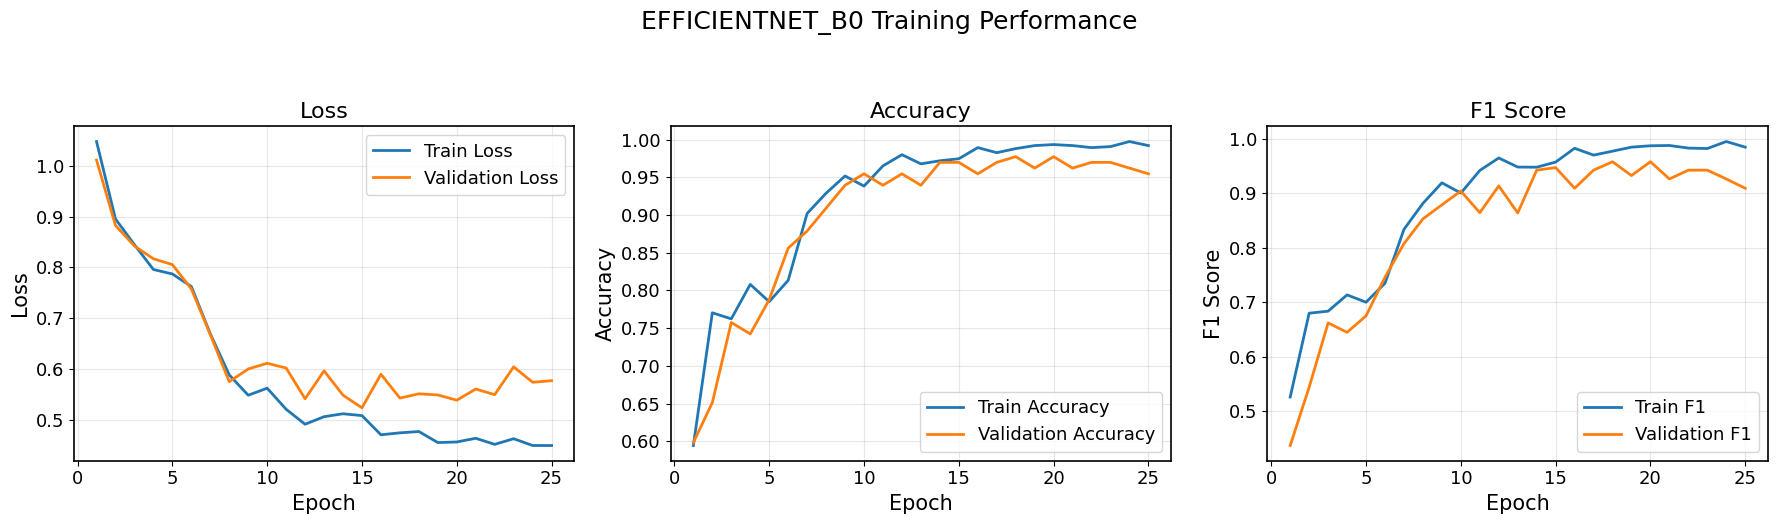

In [2]:
for model_name, history in all_histories.items():

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---- LOSS ----
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Validation Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ---- ACCURACY ----
    axes[1].plot(epochs, history["train_acc"], label="Train Accuracy")
    axes[1].plot(epochs, history["val_acc"], label="Validation Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # ---- F1 ----
    axes[2].plot(epochs, history["train_f1"], label="Train F1")
    axes[2].plot(epochs, history["val_f1"], label="Validation F1")
    axes[2].set_title("F1 Score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1 Score")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    fig.suptitle(f"{model_name.upper()} Training Performance", y=1.05)

    plt.tight_layout()

    # ✅ SVG olarak kaydet
    plt.savefig(f"{model_name}_training_curves.svg", format="svg", bbox_inches="tight")

    plt.show()

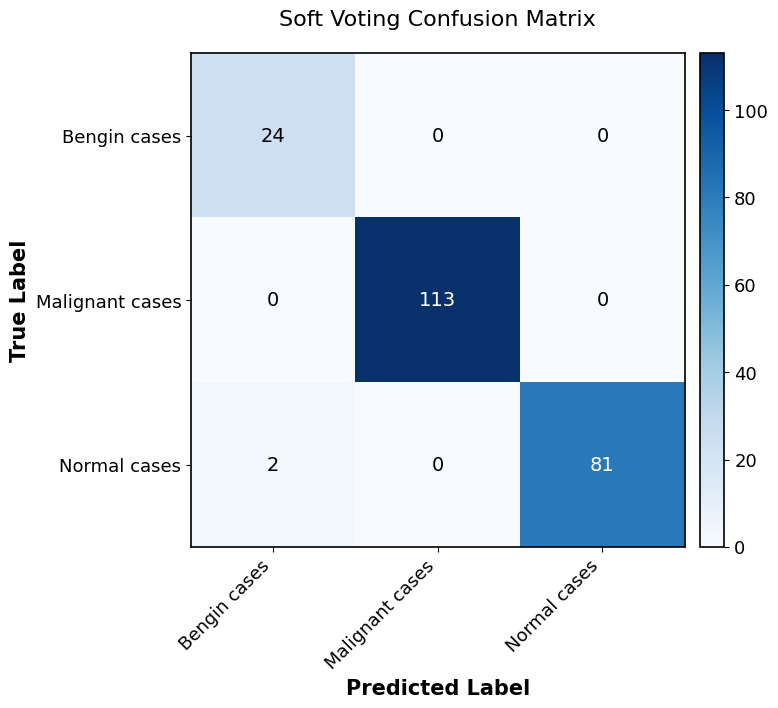

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from mpl_toolkits.axes_grid1 import make_axes_locatable # Eklenen import

# Veriler (Örnek amaçlı korunmuştur)
cm = confusion_matrix(y_true, voting_preds)
class_names = list(class_map.keys())

fig, ax = plt.subplots(figsize=(8, 8)) # Okunabilirlik için biraz büyütebilirsin
im = ax.imshow(cm, cmap="Blues")

# --- Renk Çubuğunu Boyuta Sabitleme ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15) # Sağda %5 kalınlığında bir alan açar
fig.colorbar(im, cax=cax)
# --------------------------------------

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted Label", fontweight='bold')
ax.set_ylabel("True Label", fontweight='bold')
ax.set_title("Soft Voting Confusion Matrix", pad=20)

# Hücre içi sayılar
for i in range(len(class_names)):
    for j in range(len(class_names)):
        # Sayının rengini arka plana göre ayarla (koyu mavi üstünde beyaz sayı)
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color=color, fontsize=14)

plt.tight_layout()
plt.savefig("soft_voting_confusion_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

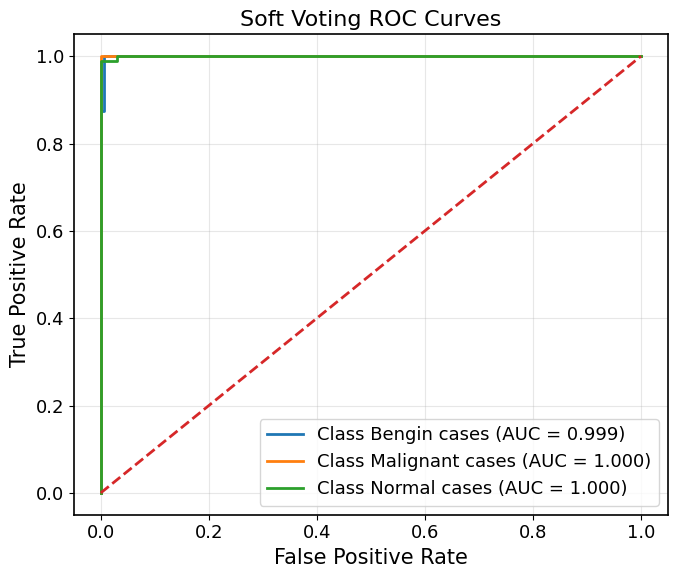

In [4]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])

fig = plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], voting_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Soft Voting ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("soft_voting_roc.svg", format="svg", bbox_inches="tight")
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Helper: unnormalize images back to viewable format
def unnormalize_img(tensor):
    img = tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

# Inverse class map (0 -> 'Bengin cases' etc.)
inv_class_map = {v: k for k, v in class_map.items()}

# Updated: Limit dynamic sample collection to 2 of each
correct_samples = []
incorrect_samples = []

m_dense = loaded_models["densenet121"]
m_res = loaded_models["resnet50"]
m_eff = loaded_models["efficientnet_b0"]

m_dense.eval()
m_res.eval()
m_eff.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        
        # Soft voting probabilities (equal weight average)
        out_dense = F.softmax(m_dense(x), dim=1)
        out_res = F.softmax(m_res(x), dim=1)
        out_eff = F.softmax(m_eff(x), dim=1)
        
        combined = (out_dense + out_res + out_eff) / 3.0
        preds = combined.argmax(1).cpu().numpy()
        labels_np = y.numpy()
        
        for i in range(len(labels_np)):
            is_correct = (preds[i] == labels_np[i])
            
            sample = {
                'tensor': x[i].unsqueeze(0),
                'image': unnormalize_img(x[i]),
                'true_label': inv_class_map[labels_np[i]],
                'pred_label': inv_class_map[preds[i]],
                'true_idx': labels_np[i]
            }
            
            # Updated to collect only 2 correct samples
            if is_correct and len(correct_samples) < 2:
                correct_samples.append(sample)
            # Collect up to 2 incorrect samples
            elif not is_correct and len(incorrect_samples) < 2:
                incorrect_samples.append(sample)

        # Break early if we have both
        if len(correct_samples) == 2 and len(incorrect_samples) == 2:
            break

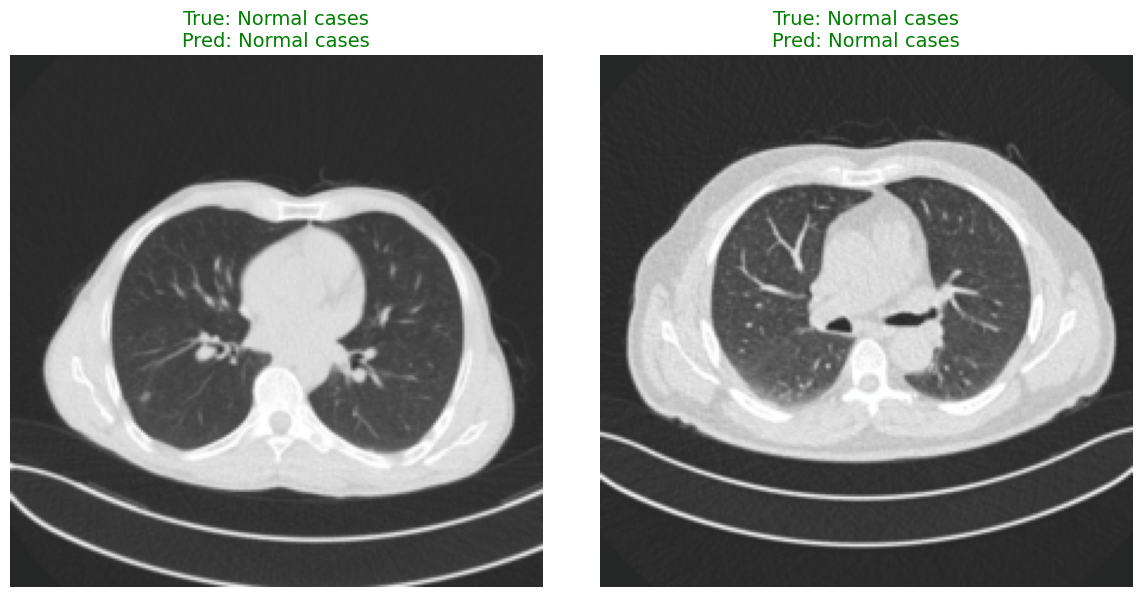

In [6]:
# =========================================
# VISUALIZATION 1: CORRECT PREDICTIONS (TOP 2 SAMPLES)
# =========================================
# subplots(1, 2) creates two columns side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Limit to 2 samples visually if somehow we have more
for i, sample in enumerate(correct_samples[:2]):
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"True: {sample['true_label']}\nPred: {sample['pred_label']}", color="green", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("correct_predictions_2samples.svg", format="svg", bbox_inches="tight")
plt.show()

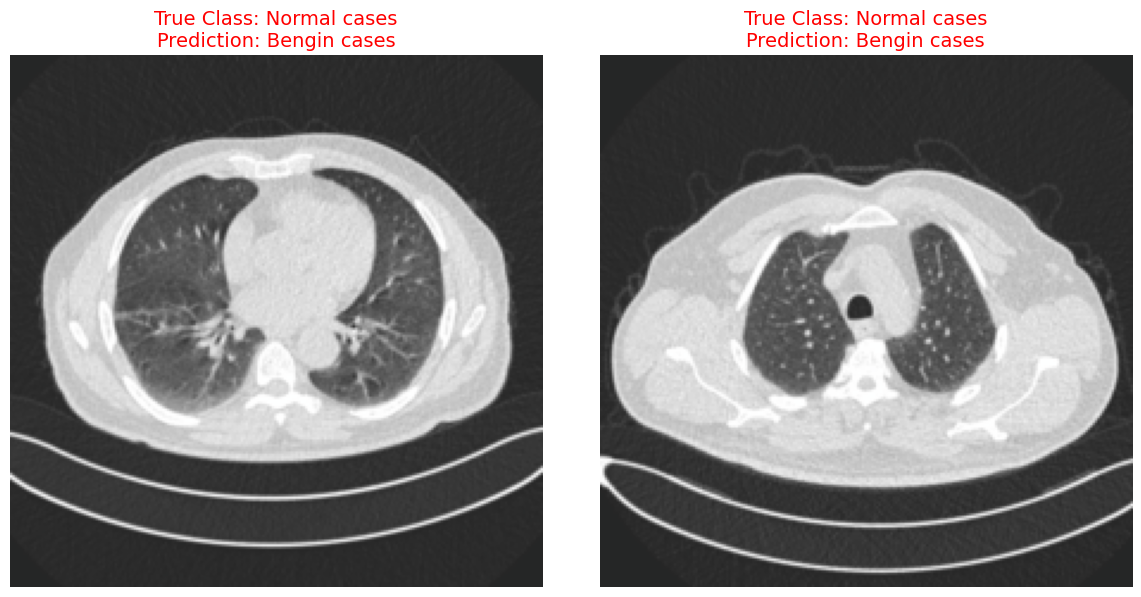

In [7]:
# =========================================
# VISUALIZATION 2: INCORRECT PREDICTIONS (TOP 2 SAMPLES)
# =========================================
num_incorrect = len(incorrect_samples)

if num_incorrect == 0:
    print("Excellent! Your ensemble model made zero errors on the unseen 'test_loader' data.")
else:
    # Dynamic subplot handling based on number of errors found (now capped at 2)
    fig, axes = plt.subplots(1, num_incorrect, figsize=(6 * num_incorrect, 6))
    
    # Handle the 'numpy.ndarray object not subscriptable' error if only 1 image exists
    if num_incorrect == 1:
        axes = [axes]
        

    for i, sample in enumerate(incorrect_samples[:2]):
        axes[i].imshow(sample['image'])
        axes[i].set_title(f"True Class: {sample['true_label']}\nPrediction: {sample['pred_label']}", color="red", fontsize=14)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig("incorrect_predictions_2samples.svg", format="svg", bbox_inches="tight")
    plt.show()

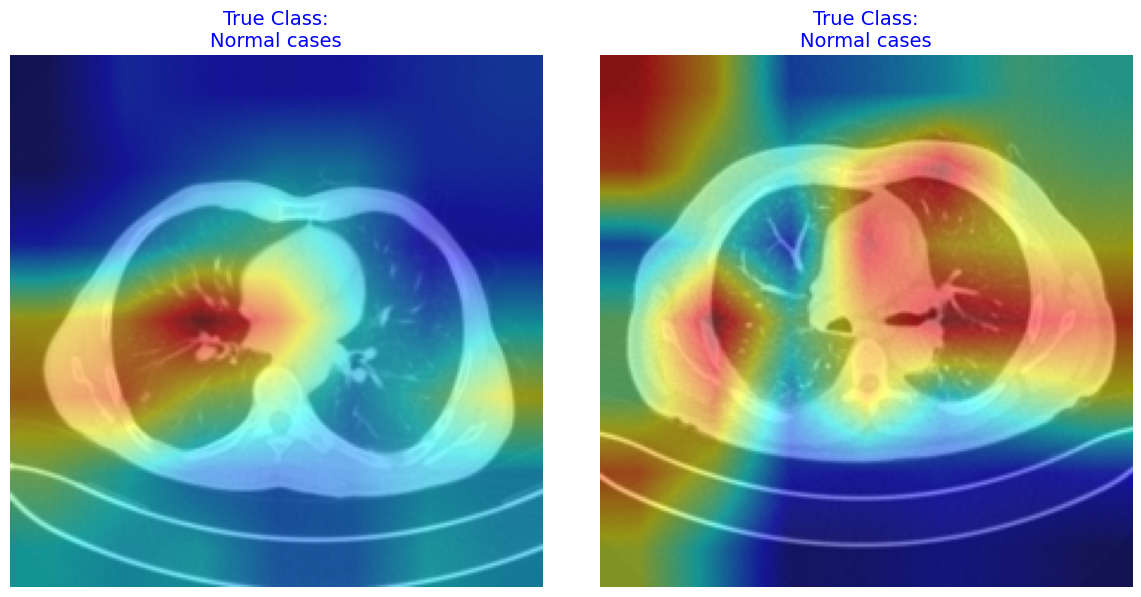

In [8]:
# =========================================
# VISUALIZATION 3: GRAD-CAM FOR CORRECT PREDICTIONS (TOP 2 SAMPLES)
# =========================================
# We use EfficientNet-b0's last convolutional layer for Grad-CAM
target_layers = [m_eff.features[-1]]
cam = GradCAM(model=m_eff, target_layers=target_layers)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, sample in enumerate(correct_samples[:2]):
    input_tensor = sample['tensor']
    target_class_idx = sample['true_idx']
    
    # Generate heatmap for the true class
    targets = [ClassifierOutputTarget(target_class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Overlay heatmap on the original image
    cam_image = show_cam_on_image(sample['image'], grayscale_cam, use_rgb=True)
    
    axes[i].imshow(cam_image)
    axes[i].set_title(f"True Class:\n{sample['true_label']}", color="blue", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("gradcam_correct_predictions_2samples.svg", format="svg", bbox_inches="tight")
plt.show()

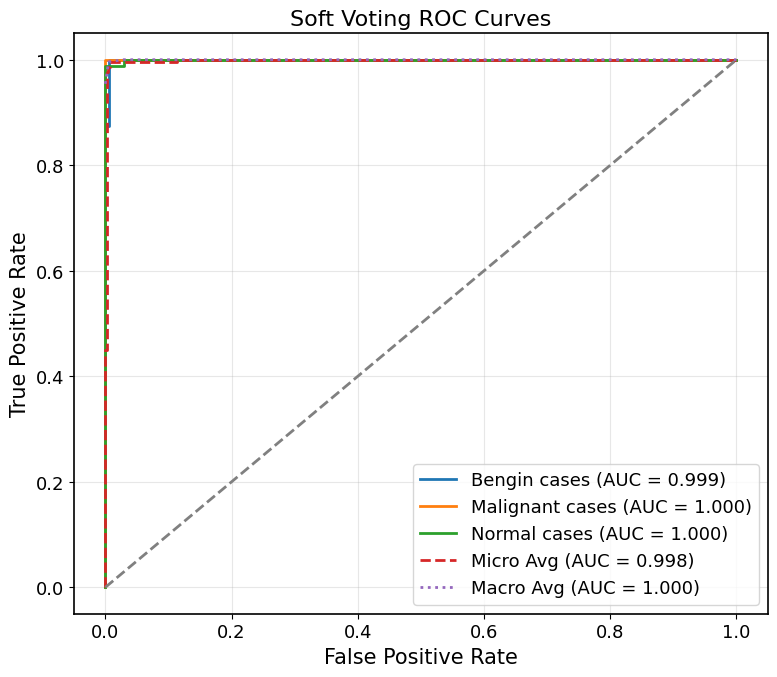


--- DEBUG ---
Bengin cases AUC: 0.9993622448979592
Malignant cases AUC: 1.0
Normal cases AUC: 0.9996482279482896
Micro AUC: 0.9981818181818182
Macro AUC: 0.999824833745828

Probability range:
Min prob: 0.0014619966
Max prob: 0.9950836

Sample probs (ilk 5):
[[0.23144104 0.02863289 0.73992604]
 [0.09693965 0.02624973 0.8768106 ]
 [0.10154432 0.7629134  0.13554229]
 [0.34384727 0.01319355 0.6429592 ]
 [0.15408003 0.817353   0.02856697]]


In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. BINARIZE LABELS
# =========================
n_classes = 3
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# =========================
# 2. ROC HESAPLAMA
# =========================
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], voting_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# =========================
# 3. MICRO AVERAGE
# =========================
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    voting_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# =========================
# 4. MACRO AVERAGE
# =========================
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# =========================
# 5. PLOT
# =========================
plt.figure(figsize=(8, 7))

# Class ROC
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Micro & Macro
plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    label=f"Micro Avg (AUC = {roc_auc['micro']:.3f})"
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    linestyle=":",
    label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})"
)

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Soft Voting ROC Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("soft_voting_roc_full.svg", format="svg", bbox_inches="tight")
plt.show()

# =========================
# 6. DEBUG (ÇOK ÖNEMLİ)
# =========================
print("\n--- DEBUG ---")
for i in range(n_classes):
    print(f"{class_names[i]} AUC:", roc_auc[i])

print("Micro AUC:", roc_auc["micro"])
print("Macro AUC:", roc_auc["macro"])

print("\nProbability range:")
print("Min prob:", np.min(voting_probs))
print("Max prob:", np.max(voting_probs))

print("\nSample probs (ilk 5):")
print(voting_probs[:5])

In [10]:
from sklearn.metrics import roc_auc_score

print(
    roc_auc_score(
        y_true_bin,
        voting_probs,
        multi_class="ovo"   # kritik değişim
    )
)

0.9996701576154163


In [11]:
# =========================
# 9. PER-MODEL DETAILED METRICS (Single Models)
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)
import torch.nn.functional as F

per_model_results = []

print("\n" + "="*70)
print("INDIVIDUAL MODEL METRICS (TEST SET)")
print("="*70)

for m_name, model in loaded_models.items():
    model.eval()
    
    all_preds = []
    all_probs = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(DEVICE)
            
            out = model(x)
            probs = F.softmax(out, dim=1)
            preds = out.argmax(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_targets.extend(y.numpy())
    
    all_preds = np.array(all_preds)
    all_probs = np.vstack(all_probs)
    all_targets = np.array(all_targets)
    
    # ---- METRICS ----
    acc = accuracy_score(all_targets, all_preds)
    
    # Macro averaged
    prec_macro = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    rec_macro = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    f1_macro = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    
    # Weighted averaged
    prec_weighted = precision_score(all_targets, all_preds, average="weighted", zero_division=0)
    rec_weighted = recall_score(all_targets, all_preds, average="weighted", zero_division=0)
    f1_weighted = f1_score(all_targets, all_preds, average="weighted", zero_division=0)
    
    # ROC-AUC (one-vs-rest)
    y_true_bin = label_binarize(all_targets, classes=[0, 1, 2])
    roc_auc_ovr = roc_auc_score(y_true_bin, all_probs, multi_class="ovr", average="macro")
    
    # Per-class metrics
    prec_per_class = precision_score(all_targets, all_preds, average=None, zero_division=0)
    rec_per_class = recall_score(all_targets, all_preds, average=None, zero_division=0)
    f1_per_class = f1_score(all_targets, all_preds, average=None, zero_division=0)
    
    # ---- PRINT ----
    print(f"\n{'='*70}")
    print(f"  MODEL: {m_name.upper()}")
    print(f"{'='*70}")
    print(f"  Accuracy            : {acc:.4f}")
    print(f"  Macro Precision     : {prec_macro:.4f}")
    print(f"  Macro Recall        : {rec_macro:.4f}")
    print(f"  Macro F1-Score      : {f1_macro:.4f}")
    print(f"  Weighted Precision  : {prec_weighted:.4f}")
    print(f"  Weighted Recall     : {rec_weighted:.4f}")
    print(f"  Weighted F1-Score   : {f1_weighted:.4f}")
    print(f"  ROC-AUC (OvR Macro) : {roc_auc_ovr:.4f}")
    
    print(f"\n  Per-Class Metrics:")
    print(f"  {'Class':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*52}")
    for i, cname in enumerate(class_names):
        print(f"  {cname:<20} {prec_per_class[i]:>10.4f} {rec_per_class[i]:>10.4f} {f1_per_class[i]:>10.4f}")
    
    print(f"\n  Full classification_report:")
    print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))
    
    # ---- STORE ----
    per_model_results.append({
        "Model": m_name,
        "Accuracy": acc,
        "Macro Precision": prec_macro,
        "Macro Recall": rec_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
        "ROC-AUC": roc_auc_ovr
    })

# =========================
# 10. SUMMARY TABLE (her model + ensemble karşılaştırması)
# =========================

# Ensemble metrikleri de tabloya ekle
ens_acc = accuracy_score(y_true, voting_preds)
ens_prec = precision_score(y_true, voting_preds, average="macro", zero_division=0)
ens_rec = recall_score(y_true, voting_preds, average="macro", zero_division=0)
ens_f1 = f1_score(y_true, voting_preds, average="macro", zero_division=0)
ens_f1_w = f1_score(y_true, voting_preds, average="weighted", zero_division=0)
ens_roc = roc_auc_score(
    label_binarize(y_true, classes=[0, 1, 2]),
    voting_probs,
    multi_class="ovr",
    average="macro"
)

per_model_results.append({
    "Model": "SoftVoting Ensemble",
    "Accuracy": ens_acc,
    "Macro Precision": ens_prec,
    "Macro Recall": ens_rec,
    "Macro F1": ens_f1,
    "Weighted F1": ens_f1_w,
    "ROC-AUC": ens_roc
})

summary_df = pd.DataFrame(per_model_results)
summary_df = summary_df.round(4)

print("\n" + "="*70)
print("SUMMARY TABLE — All Models vs Ensemble (Test Set)")
print("="*70)
print(summary_df.to_string(index=False))

# CSV olarak kaydet (makaleye doğrudan eklenebilir)
summary_df.to_csv("per_model_metrics.csv", index=False)
print("\n✅ Kaydedildi: per_model_metrics.csv")


INDIVIDUAL MODEL METRICS (TEST SET)

  MODEL: DENSENET121
  Accuracy            : 0.9864
  Macro Precision     : 0.9782
  Macro Recall        : 0.9791
  Macro F1-Score      : 0.9786
  Weighted Precision  : 0.9865
  Weighted Recall     : 0.9864
  Weighted F1-Score   : 0.9864
  ROC-AUC (OvR Macro) : 0.9997

  Per-Class Metrics:
  Class                 Precision     Recall         F1
  ----------------------------------------------------
  Bengin cases             0.9583     0.9583     0.9583
  Malignant cases          1.0000     0.9912     0.9956
  Normal cases             0.9762     0.9880     0.9820

  Full classification_report:
                 precision    recall  f1-score   support

   Bengin cases     0.9583    0.9583    0.9583        24
Malignant cases     1.0000    0.9912    0.9956       113
   Normal cases     0.9762    0.9880    0.9820        83

       accuracy                         0.9864       220
      macro avg     0.9782    0.9791    0.9786       220
   weighted avg  

In [12]:
# =========================
# 10. STATISTICAL ROBUSTNESS: BOOTSTRAP CI + MCNEMAR
# =========================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar

N_CLASSES = 3
y_true_arr = np.array(y_true)

def bootstrap_ci(y_true, probs, n_classes=N_CLASSES, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    accs, f1s, aucs = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, pr = y_true[idx], probs[idx]
        preds = pr.argmax(axis=1)
        accs.append(accuracy_score(yt, preds))
        f1s.append(f1_score(yt, preds, average="macro"))
        try:
            ybin = label_binarize(yt, classes=list(range(n_classes)))
            aucs.append(roc_auc_score(ybin, pr, average="macro", multi_class="ovr"))
        except ValueError:
            pass  # bu bootstrap örneğinde bir sınıf hiç çıkmamış olabilir, atla
    def summarize(a):
        a = np.array(a)
        return np.mean(a), np.percentile(a, 2.5), np.percentile(a, 97.5)
    return {"accuracy": summarize(accs), "macro_f1": summarize(f1s), "macro_auc": summarize(aucs)}

def mcnemar_compare(y_true, preds_a, preds_b):
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    both_correct   = int(np.sum(correct_a & correct_b))
    only_a_correct = int(np.sum(correct_a & ~correct_b))
    only_b_correct = int(np.sum(~correct_a & correct_b))
    both_wrong     = int(np.sum(~correct_a & ~correct_b))
    table = [[both_correct, only_a_correct], [only_b_correct, both_wrong]]
    res = mcnemar(table, exact=(only_a_correct + only_b_correct < 25), correction=True)
    return res.statistic, res.pvalue, table

print("=== Ensemble (soft voting) bootstrap CI ===")
ci_ens = bootstrap_ci(y_true_arr, voting_probs)
for k, (m, lo, hi) in ci_ens.items():
    print(f"{k}: {m:.4f}  [95% CI {lo:.4f}-{hi:.4f}]")

print(f"\n=== En güçlü tekil backbone ({best_single_name}) bootstrap CI ===")
ci_single = bootstrap_ci(y_true_arr, best_single_probs)
for k, (m, lo, hi) in ci_single.items():
    print(f"{k}: {m:.4f}  [95% CI {lo:.4f}-{hi:.4f}]")

print("\n=== McNemar test: Ensemble and The Most Powerful Single Backbone ===")
stat, pval, table = mcnemar_compare(y_true_arr, voting_preds, best_single_probs.argmax(1))
print(f"Contingency table [[both_correct, only_ensemble], [only_single, both_wrong]]: {table}")
print(f"McNemar statistic = {stat:.4f}, p-value = {pval:.4f}")
if pval < 0.05:
    print("-> The difference is statistically significant (p<0.05).")
else:
    print("-> The difference is NOT statistically significant (p ≥ 0.05); the improvement may be due to sampling variation.")

=== Ensemble (soft voting) bootstrap CI ===
accuracy: 0.9909  [95% CI 0.9773-1.0000]
macro_f1: 0.9825  [95% CI 0.9546-1.0000]
macro_auc: 0.9997  [95% CI 0.9985-1.0000]

=== En güçlü tekil backbone (efficientnet_b0) bootstrap CI ===
accuracy: 0.9863  [95% CI 0.9682-1.0000]
macro_f1: 0.9786  [95% CI 0.9512-1.0000]
macro_auc: 0.9944  [95% CI 0.9818-1.0000]

=== McNemar test: Ensemble and The Most Powerful Single Backbone ===
Contingency table [[both_correct, only_ensemble], [only_single, both_wrong]]: [[216, 2], [1, 1]]
McNemar statistic = 1.0000, p-value = 1.0000
-> The difference is NOT statistically significant (p ≥ 0.05); the improvement may be due to sampling variation.


In [13]:
# =========================
# 11. LUNG CT — MULTI-SEED ROBUSTNESS (Opsiyon 1)
# =========================
from sklearn.metrics import accuracy_score

def run_lung_ct_seed_experiment(seed, model_names=("densenet121", "resnet50", "efficientnet_b0"),
                                 max_epochs=50, patience=7):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # shuffle sırası seed'e bağlı olsun diye train_loader'ı bu seed için yeniden kuruyoruz
    seed_train_loader = DataLoader(LungDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True)

    seed_probs, seed_metrics = {}, []

    for m_name in model_names:
        if m_name == "densenet121":
            model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
            model.classifier = nn.Linear(model.classifier.in_features, 3)
        elif m_name == "resnet50":
            model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            model.fc = nn.Linear(model.fc.in_features, 3)
        else:
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)

        model = model.to(DEVICE)
        for p in model.parameters():
            p.requires_grad = False
        if m_name == "densenet121":
            for p in model.classifier.parameters(): p.requires_grad = True
        elif m_name == "resnet50":
            for p in model.fc.parameters(): p.requires_grad = True
        else:
            for p in model.classifier.parameters(): p.requires_grad = True

        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                       lr=3e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

        best_f1, counter = 0, 0
        save_path = f"seed{seed}_best_{m_name}.pth"

        for epoch in range(max_epochs):
            if epoch == 5:
                for p in model.parameters(): p.requires_grad = True
                optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

            train_one_epoch(model, seed_train_loader, optimizer, criterion)
            _, val_f1, _, _, _ = eval_one_epoch(model, val_loader, criterion)
            scheduler.step(val_f1)

            if val_f1 > best_f1:
                best_f1, counter = val_f1, 0
                torch.save(model.state_dict(), save_path)
            else:
                counter += 1
            if counter >= patience:
                break

        model.load_state_dict(torch.load(save_path))
        _, test_f1, test_acc, y_prob, y_t = eval_one_epoch(model, test_loader, criterion)
        test_auc = roc_auc_score(
            torch.nn.functional.one_hot(torch.tensor(y_t), num_classes=3),
            y_prob, multi_class="ovr"
        )
        seed_probs[m_name] = y_prob
        seed_metrics.append({"seed": seed, "model": m_name,
                              "test_f1": test_f1, "test_acc": test_acc, "test_auc": test_auc})

    # bu seed için soft-voting ensemble
    ens_probs = np.mean([seed_probs[m] for m in model_names], axis=0)
    ens_preds = ens_probs.argmax(1)
    seed_metrics.append({
        "seed": seed, "model": "ENSEMBLE",
        "test_f1": f1_score(y_t, ens_preds, average="macro"),
        "test_acc": accuracy_score(y_t, ens_preds),
        "test_auc": roc_auc_score(torch.nn.functional.one_hot(torch.tensor(y_t), num_classes=3),
                                   ens_probs, multi_class="ovr")
    })
    return seed_metrics, seed_probs, y_t

In [14]:
all_seed_metrics = []

for m_name in model_names:
    row = comparison_df[comparison_df["Model"] == m_name].iloc[0]
    all_seed_metrics.append({"seed": 42, "model": m_name,
                              "test_f1": row["Test F1"], "test_acc": None,
                              "test_auc": row["Test ROC-AUC"]})

all_seed_metrics.append({
    "seed": 42, "model": "ENSEMBLE",
    "test_f1": f1_score(y_true, voting_preds, average="macro"),
    "test_acc": accuracy_score(y_true, voting_preds),
    "test_auc": roc_auc_score(torch.nn.functional.one_hot(torch.tensor(y_true), num_classes=3),
                               voting_probs, multi_class="ovr")
})

In [15]:
extra_seeds = [123, 2024]

for s in extra_seeds:
    print(f"\n########## SEED {s} — LUNG CT ##########")
    metrics, probs, yt = run_lung_ct_seed_experiment(s)
    all_seed_metrics.extend(metrics)

multiseed_df = pd.DataFrame(all_seed_metrics)
print(multiseed_df)

summary = (multiseed_df
           .groupby("model")[["test_f1", "test_acc", "test_auc"]]
           .agg(["mean", "std"])
           .round(4))
print("\n=== Lung CT — 3-seed summary (mean ± std) ===")
print(summary)

multiseed_df.to_csv("lung_ct_multiseed_results.csv", index=False)


########## SEED 123 — LUNG CT ##########

########## SEED 2024 — LUNG CT ##########
    seed            model   test_f1  test_acc  test_auc
0     42      densenet121  0.978642       NaN  0.999682
1     42         resnet50  0.903255       NaN  0.996550
2     42  efficientnet_b0  0.979063       NaN  0.994383
3     42         ENSEMBLE  0.982602  0.990909  0.999670
4    123      densenet121  0.966129  0.981818  0.999765
5    123         resnet50  0.963078  0.981818  0.990102
6    123  efficientnet_b0  0.970693  0.981818  0.999111
7    123         ENSEMBLE  0.974257  0.986364  0.999699
8   2024      densenet121  0.961854  0.981818  0.999812
9   2024         resnet50  0.885814  0.931818  0.990701
10  2024  efficientnet_b0  0.982602  0.990909  0.999971
11  2024         ENSEMBLE  0.970693  0.981818  0.999423

=== Lung CT — 3-seed summary (mean ± std) ===
                test_f1         test_acc         test_auc        
                   mean     std     mean     std     mean     std
model   